 ## In this class...
  - Binomial distribution (``scipy.stats.binom.pmf(n=n,p=p,k=k)``)
  - Normal distribution (``scipy.stats.norm.cdf(x)``)
  - Confidence Intervals (``scipy.stats.norm.ppf(x)``)

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import statistics

from numpy import random
from scipy.stats import norm


from pathlib import Path
print('Imported libraries')

Imported libraries


In [ ]:
from scipy.stats import binom

# Someone is in a free throw contest, with a probability of scoring a free throw (independent event) of 0.6.
# Lets see the probability of scoring 3 free throws if throwing 5 times

p = 0.7
k=3
n=5

prob_3_exact = binom.pmf(n=n, p=p, k=k)

print(f'Probability of scoring 3/5: {prob_3_exact:.3f}')

Probability of scoring 3/5: 0.309


In [ ]:
# What about 3 or more?
# I'll calculate 2 or less, and do 1 - p_2_or_less

p_2_or_less = 0

for i in range(3):
    p_i = binom.pmf(k=i, n=n, p=p)
    p_2_or_less += p_i

print(f'Probability of scoring 3/5: {1-p_2_or_less:.3f}')

Probability of scoring 3/5: 0.837


Text(0.5, 1.0, 'Binomial PMF for Free Throws')

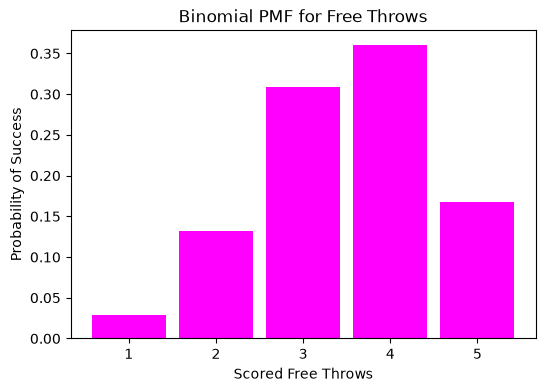

In [ ]:
x=np.arange(1,6)
ppp = binom.pmf(n=n, p=p, k=x)


fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, ppp, width=0.85, color = 'magenta')

ax.set_xlabel('Scored Free Throws')
ax.set_ylabel('Probability of Success') 
ax.set_title('Binomial PMF for Free Throws')

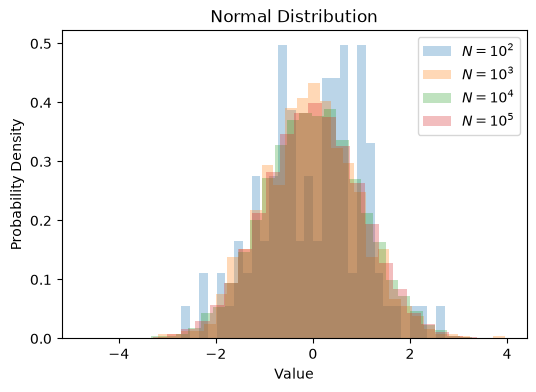

In [ ]:
# (Standard) Normal distribution:

rng = random.default_rng(19)


fig, ax = plt.subplots(figsize=(6, 4))



for i in range(4):
    N = i+2
    rnd_n = rng.normal(size=10**N)
    ax.hist(rnd_n, label=f'$N=10^{N}$', alpha=0.3, bins=30, density=True)

ax.set_title('Normal Distribution')
ax.set_xlabel('Value')
ax.set_ylabel('Probability Density')
ax.legend()

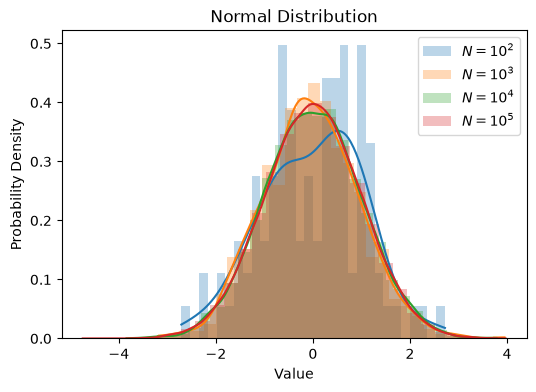

In [ ]:
# With seaborn I can include KDE easily

rng = random.default_rng(19)

fig, ax = plt.subplots(figsize=(6, 4))

for i in range(4):
    N = i+2
    rnd_n = rng.normal(size=10**N)
    sns.histplot(rnd_n, label=f'$N=10^{N}$', alpha=0.3, bins=30, stat='density', kde=True, ax=ax, edgecolor='none')


ax.set_title('Normal Distribution')
ax.set_xlabel('Value')
ax.set_ylabel('Probability Density')
ax.legend()

In [ ]:
rng = random.default_rng(19)

x=rng.normal()

prob = norm.cdf(x) # cdf = Cumulative Distribution Function: cdf(x) = P(X < x)

print(f"P(X < x = {x:.2f}) = {prob:.2f}")

P(X < x = -0.37) = 0.36


In [ ]:
# Confidence intervals (useful if using samples of a populations)

# For making things easier, I'll create my own function for standard normal distributions
def norm_conf_int(conf_int: int):
    if conf_int >= 0 and conf_int <= 1:
        c_int = (1- (1-conf_int)/2)
        return norm.ppf(c_int)
    else:
        raise ValueError('conf_int should be between 0 and 1')

In [ ]:
# Imagine: 
std = 20
bar_x = 90
sample = 250

# What's the confidence interval of 90% for the mean of the population (mu)?

i90 = norm_conf_int(0.9)
error_margin = i90 * std / np.sqrt(250)

print(rf'Confidence interval: {bar_x} +- {error_margin:.2f} = [{bar_x - error_margin:.2f}, {bar_x + error_margin:.2f}]')

Confidence interval: 90 +- 2.08 = [87.92, 92.08]
